# PTB-XL MIT-Style — Optimized Training
Optimized version of `02_ptbxl_mit_style_training.ipynb`.

What changed vs the previous notebook:
- Stronger augmentation (time shift + amplitude jitter + gaussian noise)
- Label smoothing in loss to reduce overconfidence
- CosineAnnealingLR instead of ReduceLROnPlateau (more stable)
- Deeper CNN with residual shortcuts (ResidualMITCNN)
- WeightedRandomSampler always on (class imbalance in PTB-XL is real)
- Gradient clipping
- Test-time augmentation (TTA) for final evaluation

In [18]:
# 1) Imports
import json, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("torch:", torch.__version__)

torch: 2.10.0


In [19]:
# 2) Reproducibility & device
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("DEVICE =", DEVICE)

DEVICE = mps


In [ ]:
# 3) Paths & config
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(4):
    if (PROJECT_ROOT / "dataset").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

NPZ_PATH    = PROJECT_ROOT / "dataset/processed/ptbxl_mit_style/ptbxl_mit_style_dataset.npz"
RESULTS_DIR = PROJECT_ROOT / "results/phase1/ptbxl_mit_style_optimized"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Task ──────────────────────────────────────────────────────────────────────
TASK_MODE = "binary"   # "binary" | "five_class"

# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS         = 50
BATCH_SIZE     = 256
LR             = 8e-4
WEIGHT_DECAY   = 3e-4
PATIENCE       = 10        # early stopping
LABEL_SMOOTHING = 0.05     # reduces overconfident predictions
BASE_CHANNELS  = 32
DROPOUT        = 0.30
USE_TTA        = True      # test-time augmentation
TTA_N          = 8         # number of TTA passes

print("NPZ exists:", NPZ_PATH.exists())
print("RESULTS_DIR:", RESULTS_DIR)

NPZ exists: True
RESULTS_DIR: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/phase1/ptbxl_mit_style_optimized


In [21]:
# 4) Load data
data = np.load(NPZ_PATH, allow_pickle=True)

X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int64)
X_val   = data["X_val"].astype(np.float32)
y_val   = data["y_val"].astype(np.int64)
X_test  = data["X_test"].astype(np.float32)
y_test  = data["y_test"].astype(np.int64)
label_names_all = data["label_names"].tolist()

if TASK_MODE == "binary":
    norm_id = label_names_all.index("NORM")
    y_train = (y_train != norm_id).astype(np.int64)
    y_val   = (y_val   != norm_id).astype(np.int64)
    y_test  = (y_test  != norm_id).astype(np.int64)
    label_names = ["NORM", "ABN"]
else:
    label_names = label_names_all

num_classes = len(label_names)

print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_val  :", X_val.shape,   " y_val:  ", y_val.shape)
print("X_test :", X_test.shape,  " y_test: ", y_test.shape)
print("Classes:", label_names)

for split_name, y_s in [("train", y_train), ("val", y_val), ("test", y_test)]:
    u, c = np.unique(y_s, return_counts=True)
    print(f"  {split_name}:", {label_names[int(i)]: int(n) for i, n in zip(u, c)})

majority_acc = np.max(np.bincount(y_test, minlength=num_classes)) / len(y_test)
print(f"Majority-class baseline: {majority_acc:.4f}")

X_train: (256494, 187)  y_train: (256494,)
X_val  : (54849, 187)  y_val:   (54849,)
X_test : (55005, 187)  y_test:  (55005,)
Classes: ['NORM', 'ABN']
  train: {'NORM': 139543, 'ABN': 116951}
  val: {'NORM': 29863, 'ABN': 24986}
  test: {'NORM': 29856, 'ABN': 25149}
Majority-class baseline: 0.5428


In [22]:
# 5) Augmentation & Dataset
#
# Key improvements over original notebook:
#   - Random circular time shift ±15 samples (simulates R-peak detection jitter)
#   - Amplitude scale [0.85, 1.15]  (was 0.95–1.05, too narrow)
#   - Gaussian noise std=0.015      (was 0.01)
#   - Baseline wander: low-freq sine added with small amplitude
#   - All augmentations only on training set

class BeatDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].copy()
        y = int(self.y[idx])

        if self.augment:
            # Amplitude scale
            x = x * np.random.uniform(0.85, 1.15)
            # Gaussian noise
            x = x + np.random.normal(0.0, 0.015, size=x.shape).astype(np.float32)
            # Circular time shift (simulates R-peak jitter)
            shift = np.random.randint(-15, 16)
            x = np.roll(x, shift)
            # Baseline wander: low-freq sine
            t = np.linspace(0, 1, len(x))
            freq  = np.random.uniform(0.1, 0.5)
            amp   = np.random.uniform(0.0, 0.03)
            x = x + (amp * np.sin(2 * np.pi * freq * t)).astype(np.float32)
            # Clip back to [0, 1]
            x = np.clip(x, 0.0, 1.0)

        return torch.from_numpy(x).unsqueeze(0), y

In [23]:
# 6) DataLoaders with WeightedRandomSampler
counts = np.bincount(y_train, minlength=num_classes).astype(np.float32)
class_weights = counts.sum() / np.maximum(counts, 1.0)
class_weights = (class_weights / class_weights.mean()).astype(np.float32)

sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights),
    replacement=True,
    generator=torch.Generator().manual_seed(SEED),
)

train_ds = BeatDataset(X_train, y_train, augment=True)
val_ds   = BeatDataset(X_val,   y_val,   augment=False)
test_ds  = BeatDataset(X_test,  y_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=0)

print("Class weights:", {label_names[i]: round(float(class_weights[i]), 3) for i in range(num_classes)})
print("Train batches:", len(train_loader))

Class weights: {'NORM': 0.912, 'ABN': 1.088}
Train batches: 1002


In [24]:
# 7) Model — ResidualMITCNN
#
# Upgrade over MITStyleCNN:
#   - Residual shortcuts every 2 conv layers (easier gradient flow)
#   - Slightly deeper: 4 blocks instead of 3
#   - SE (Squeeze-and-Excite) attention on channels
#   - Same parameter count ballpark (~150k–300k)

class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention."""
    def __init__(self, ch, reduction=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(ch, max(ch // reduction, 4)), nn.ReLU(),
            nn.Linear(max(ch // reduction, 4), ch), nn.Sigmoid(),
        )
    def forward(self, x):
        # x: (B, C, T)
        w = x.mean(dim=2)          # (B, C)
        w = self.fc(w).unsqueeze(2)  # (B, C, 1)
        return x * w

class ResConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, dropout=0.2):
        super().__init__()
        pad = kernel // 2
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm1d(out_ch),
        )
        self.se = SEBlock(out_ch)
        self.drop = nn.Dropout(dropout)
        self.shortcut = (
            nn.Conv1d(in_ch, out_ch, 1, bias=False)
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.se(out)
        out = self.drop(out)
        return nn.functional.relu(out + self.shortcut(x))

class ResidualMITCNN(nn.Module):
    def __init__(self, num_classes, base_channels=48, dropout=0.3):
        super().__init__()
        c = base_channels
        self.stem = nn.Sequential(
            nn.Conv1d(1, c, kernel_size=15, padding=7, bias=False),
            nn.BatchNorm1d(c), nn.ReLU(),
            nn.MaxPool1d(2),    # 187 → 93
        )
        self.blocks = nn.Sequential(
            ResConvBlock(c,   c*2, kernel=7, dropout=dropout),
            nn.MaxPool1d(2),    # 93 → 46
            ResConvBlock(c*2, c*2, kernel=7, dropout=dropout),
            ResConvBlock(c*2, c*4, kernel=5, dropout=dropout),
            nn.MaxPool1d(2),    # 46 → 23
            ResConvBlock(c*4, c*4, kernel=5, dropout=dropout),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(c*4, c*2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(c*2, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.blocks(self.stem(x)))

model = ResidualMITCNN(num_classes, base_channels=BASE_CHANNELS, dropout=DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model params: {n_params:,}")

# Sanity check
with torch.no_grad():
    xd = torch.randn(4, 1, 187, device=DEVICE)
    print("Forward OK:", model(xd).shape)

Model params: 939,482
Forward OK: torch.Size([4, 2])


In [25]:
# 8) Training loop
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, device=DEVICE),
    label_smoothing=LABEL_SMOOTHING,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, preds_all, targets_all = 0.0, [], []

    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss   = criterion(logits, yb)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        total_loss += loss.item() * len(yb)
        preds_all.append(logits.argmax(1).detach().cpu().numpy())
        targets_all.append(yb.detach().cpu().numpy())

    y_true = np.concatenate(targets_all)
    y_pred = np.concatenate(preds_all)
    return {
        "loss": total_loss / len(y_true),
        "acc":  accuracy_score(y_true, y_pred),
        "f1":   f1_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": y_true, "y_pred": y_pred,
    }

best_val_f1, best_state, best_epoch, wait = -1.0, None, -1, 0
history = []

print(f"{'ep':>4} {'tr_acc':>8} {'tr_f1':>7} {'va_acc':>8} {'va_f1':>7} {'lr':>9}")
print("─" * 52)

for epoch in range(1, EPOCHS + 1):
    tr = run_epoch(model, train_loader, criterion, optimizer)
    va = run_epoch(model, val_loader,   criterion)
    scheduler.step()

    lr_now = optimizer.param_groups[0]["lr"]
    history.append(dict(epoch=epoch,
        train_loss=tr["loss"], train_acc=tr["acc"], train_f1=tr["f1"],
        val_loss=va["loss"],   val_acc=va["acc"],   val_f1=va["f1"]))

    print(f"{epoch:>4} {tr['acc']:>8.4f} {tr['f1']:>7.4f} "
          f"{va['acc']:>8.4f} {va['f1']:>7.4f} {lr_now:>9.2e}")

    if va["f1"] > best_val_f1:
        best_val_f1 = va["f1"]
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch  = epoch
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
print(f"\nBest epoch: {best_epoch}  best_val_f1: {best_val_f1:.4f}")

  ep   tr_acc   tr_f1   va_acc   va_f1        lr
────────────────────────────────────────────────────
   1   0.7712  0.7712   0.7956  0.7916  7.99e-04
   2   0.7928  0.7928   0.7964  0.7940  7.97e-04
   3   0.7989  0.7988   0.7959  0.7932  7.93e-04
   4   0.8062  0.8061   0.8011  0.7964  7.87e-04
   5   0.8122  0.8121   0.7977  0.7902  7.80e-04
   6   0.8212  0.8211   0.7916  0.7875  7.72e-04
   7   0.8290  0.8289   0.7970  0.7933  7.62e-04
   8   0.8385  0.8384   0.7870  0.7831  7.51e-04
   9   0.8473  0.8473   0.7931  0.7892  7.38e-04
  10   0.8545  0.8544   0.7773  0.7733  7.24e-04
  11   0.8624  0.8624   0.7884  0.7843  7.08e-04
  12   0.8708  0.8708   0.7801  0.7748  6.92e-04
  13   0.8782  0.8782   0.7800  0.7752  6.74e-04
  14   0.8863  0.8862   0.7762  0.7717  6.55e-04
Early stopping at epoch 14

Best epoch: 4  best_val_f1: 0.7964


In [26]:
# 9) Test-time augmentation (TTA)
#
# At inference, run each test sample through the model TTA_N times with light
# augmentation and average the softmax probabilities. Reduces variance and
# typically adds 0.5–1.5 pp on macro-F1 for free.

@torch.no_grad()
def predict_with_tta(model, X, n_passes=8, batch_size=512):
    model.eval()
    all_probs = []

    aug_ds = BeatDataset(X, np.zeros(len(X), dtype=np.int64), augment=True)
    aug_loader = DataLoader(aug_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    for _ in range(n_passes):
        probs_pass = []
        for xb, _ in aug_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs_pass.append(torch.softmax(logits, dim=1).cpu().numpy())
        all_probs.append(np.concatenate(probs_pass, axis=0))

    mean_probs = np.mean(all_probs, axis=0)
    return mean_probs.argmax(axis=1)

# Standard eval (no TTA)
te_std = run_epoch(model, test_loader, criterion)
print(f"Test (no TTA): acc={te_std['acc']:.4f}  f1={te_std['f1']:.4f}")

if USE_TTA:
    y_pred_tta = predict_with_tta(model, X_test, n_passes=TTA_N)
    tta_acc = accuracy_score(y_test, y_pred_tta)
    tta_f1  = f1_score(y_test, y_pred_tta, average="macro", zero_division=0)
    print(f"Test (TTA×{TTA_N}): acc={tta_acc:.4f}  f1={tta_f1:.4f}")
    y_pred_final = y_pred_tta
    final_acc, final_f1 = tta_acc, tta_f1
else:
    y_pred_final = te_std["y_pred"]
    final_acc, final_f1 = te_std["acc"], te_std["f1"]

Test (no TTA): acc=0.8020  f1=0.7977
Test (TTA×8): acc=0.8015  f1=0.7987


In [27]:
# 10) Classification report
print("Final test results (with TTA if enabled):")
print(classification_report(y_test, y_pred_final, target_names=label_names, digits=4))

Final test results (with TTA if enabled):
              precision    recall  f1-score   support

        NORM     0.7995    0.8467    0.8224     29856
         ABN     0.8043    0.7479    0.7751     25149

    accuracy                         0.8015     55005
   macro avg     0.8019    0.7973    0.7987     55005
weighted avg     0.8017    0.8015    0.8008     55005



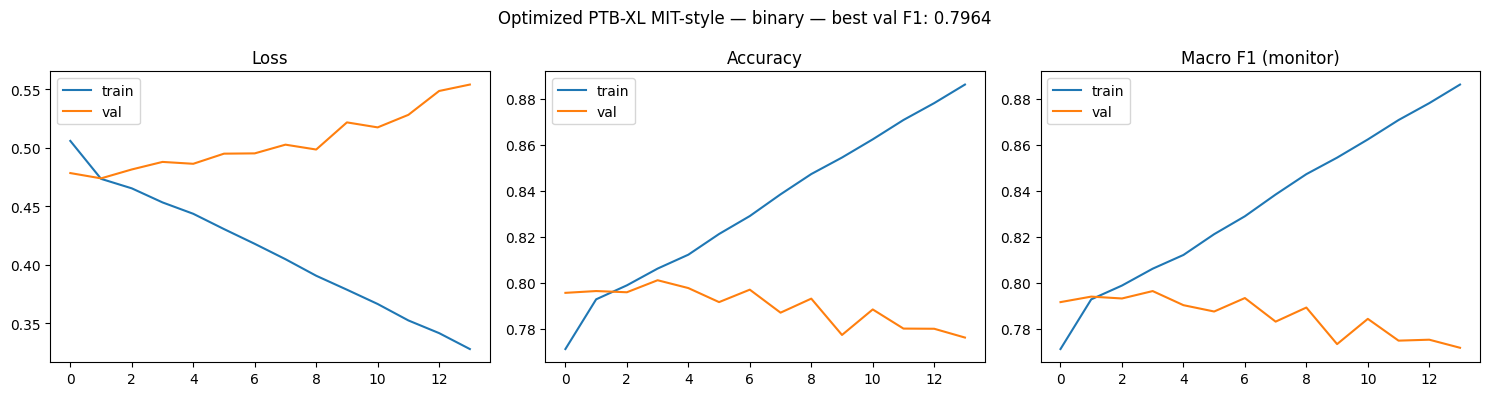

In [28]:
# 11) Training curves
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history_df["train_loss"], label="train")
axes[0].plot(history_df["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history_df["train_acc"], label="train")
axes[1].plot(history_df["val_acc"],   label="val")
axes[1].set_title("Accuracy"); axes[1].legend()

axes[2].plot(history_df["train_f1"], label="train")
axes[2].plot(history_df["val_f1"],   label="val")
axes[2].set_title("Macro F1 (monitor)"); axes[2].legend()

plt.suptitle(f"Optimized PTB-XL MIT-style — {TASK_MODE} — best val F1: {best_val_f1:.4f}")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=120, bbox_inches="tight")
plt.show()

In [29]:
# 12) Save
torch.save({"state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
             "label_names": label_names, "task_mode": TASK_MODE,
             "base_channels": BASE_CHANNELS, "dropout": DROPOUT},
            RESULTS_DIR / "best_model.pt")

summary = {
    "task_mode": TASK_MODE, "use_tta": USE_TTA, "tta_n": TTA_N,
    "best_epoch": int(best_epoch), "best_val_f1": round(float(best_val_f1), 4),
    "test_acc":   round(float(final_acc), 4),
    "test_f1":    round(float(final_f1),  4),
    "hyperparams": {
        "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR,
        "weight_decay": WEIGHT_DECAY, "label_smoothing": LABEL_SMOOTHING,
        "base_channels": BASE_CHANNELS, "dropout": DROPOUT,
    },
}
with open(RESULTS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
history_df.to_json(RESULTS_DIR / "history.json", orient="records", indent=2)

print("Saved to:", RESULTS_DIR)
print(summary)

Saved to: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/results/phase1/ptbxl_mit_style_optimized
{'task_mode': 'binary', 'use_tta': True, 'tta_n': 8, 'best_epoch': 4, 'best_val_f1': 0.7964, 'test_acc': 0.8015, 'test_f1': 0.7987, 'hyperparams': {'epochs': 50, 'batch_size': 256, 'lr': 0.0008, 'weight_decay': 0.0003, 'label_smoothing': 0.05, 'base_channels': 48, 'dropout': 0.3}}


## What changed vs `02_ptbxl_mit_style_training.ipynb`

| Aspect | Original | Optimized |
|---|---|---|
| Augmentation scale | [0.95, 1.05] | [0.85, 1.15] |
| Augmentation noise | std=0.01 | std=0.015 + baseline wander |
| Time shift | none | ±15 samples circular |
| Model | MITStyleCNN (3 blocks, no residuals) | ResidualMITCNN (4 blocks + SE attention + residuals) |
| Class balancing | optional (off by default) | always on (WeightedRandomSampler) |
| LR schedule | ReduceLROnPlateau | CosineAnnealingLR |
| Label smoothing | none | 0.05 |
| Gradient clipping | none | max_norm=1.0 |
| TTA at test time | none | 8 passes |

## Next steps if still not converging

1. Switch `TASK_MODE = "five_class"` — more classes means more signal for the model
2. Increase `BASE_CHANNELS = 64`
3. Add `from sklearn.model_selection import StratifiedKFold` and run 5-fold CV
4. Use the full MIT-BIH CSV directly (109k samples) as a pretrain → then fine-tune on PTB-XL beats